# <center>Homework 99</center>

## Task 1

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import time

### MNIST fashion

In [36]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [37]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

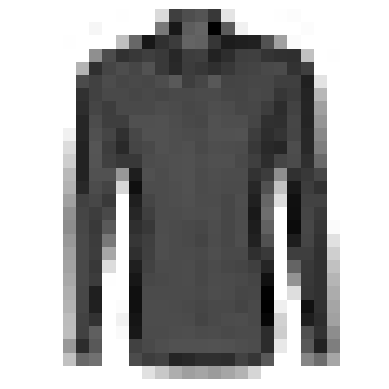

In [27]:
plt.imshow(X_train[40], cmap="binary")
plt.axis('off')
plt.show()

In [28]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [29]:
tf.random.set_seed(42) 
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss="sparse_categorical_crossentropy",
            optimizer="sgd",
            metrics=["accuracy"])

In [32]:
model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30


2025-12-29 14:43:38.396989: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7626 - loss: 0.7146 - val_accuracy: 0.8260 - val_loss: 0.5102
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8303 - loss: 0.4901 - val_accuracy: 0.8382 - val_loss: 0.4579
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8452 - loss: 0.4453 - val_accuracy: 0.8460 - val_loss: 0.4341
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8539 - loss: 0.4171 - val_accuracy: 0.8488 - val_loss: 0.4168
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8598 - loss: 0.3965 - val_accuracy: 0.8534 - val_loss: 0.4031
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8664 - loss: 0.3798 - val_accuracy: 0.8566 - val_loss: 0.3926
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8710 - loss: 0.3659 - val_accuracy: 0.8580 - val_loss: 0.3858
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8754 - loss: 0.3539 - val

In [34]:
loss, tf_acc = model.evaluate(X_test, y_test)
tf_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8767 - loss: 0.3566


0.8766999840736389

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [45]:
ser = pd.Series(y_train)
((ser.value_counts() / len(ser)) * 100).sort_index()

0     9.961818
1    10.005455
2    10.018182
3     9.985455
4     9.950909
5     9.994545
6    10.060000
7    10.090909
8     9.972727
9     9.960000
Name: count, dtype: float64

In [47]:
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

In [48]:
mlp_clf = MLPClassifier((300, 100), solver='sgd', random_state=42).fit(X_train, y_train)
y_test_pred = mlp_clf.predict(X_test)
mlp_clf_acc = accuracy_score(y_test, y_test_pred)
mlp_clf_acc

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.8844

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
forest_clf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_test_pred = forest_clf.predict(X_test)
forest_clf_acc = accuracy_score(y_test, y_test_pred)
forest_clf_acc

0.8757

In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
knn = KNeighborsClassifier().fit(X_train, y_train)
y_test_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_test_pred)
knn_acc

0.8535

In [53]:
from sklearn.linear_model import SGDClassifier

In [54]:
sgd_clf = SGDClassifier(random_state=42).fit(X_train, y_train)
y_test_pred = sgd_clf.predict(X_test)
sgd_clf_acc = accuracy_score(y_test, y_test_pred)
sgd_clf_acc

0.8335

In [55]:
print('----------------- Fashion MNIST Dataset -----------------')
models = ['TF Sequential', 'MLPClassifier', 'RandomForestClassifier', 'KNNClassifier', 'SGDClassifier']

pd.DataFrame([
    [tf_acc, '5m'],
    [mlp_clf_acc, '22m'],
    [forest_clf_acc, '2m'],
    [knn_acc, '20sec'],
    [sgd_clf_acc, '35sec']
], models, ['Accuracy', 'Fit Time'])

----------------- Fashion MNIST Dataset -----------------


,Accuracy,Fit Time
TF Sequential,0.8767,5m
MLPClassifier,0.8844,22m
RandomForestClassifier,0.8757,2m
KNNClassifier,0.8535,20sec
SGDClassifier,0.8335,35sec


### MNIST digits

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')
X = mnist.data.values
y = mnist.target.to_numpy().astype(int)

X_train_full, y_train_full, X_test, y_test = X[:60_000], y[:60_000], X[60_000:], y[60_000:]
X_train, y_train, X_val, y_val = X_train_full[:55_000], y_train_full[:55_000], X_train_full[55_000:], y_train_full[55_000:]

In [4]:
X_train, X_val, X_test = X_train / 255., X_val / 255., X_test / 255.

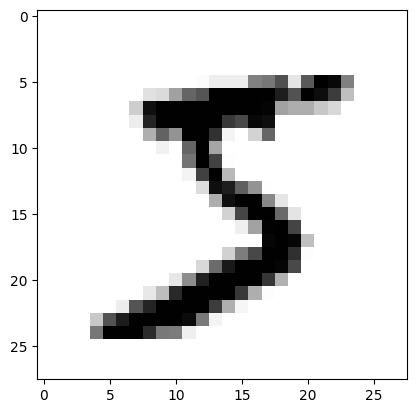

In [5]:
plt.imshow(X[0].reshape(28, 28), cmap='binary')

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(X.shape[1:]),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
model.summary()

2025-12-30 00:57:50.078533: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
start = time.time()
model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))
end = time.time()
tf_fittime = end - start

2025-12-30 00:58:43.020219: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 172480000 exceeds 10% of free system memory.


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8447 - loss: 0.6098 - val_accuracy: 0.9316 - val_loss: 0.2588
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9171 - loss: 0.2913 - val_accuracy: 0.9446 - val_loss: 0.2032
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9325 - loss: 0.2365 - val_accuracy: 0.9542 - val_loss: 0.1698
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9430 - loss: 0.2007 - val_accuracy: 0.9622 - val_loss: 0.1509
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9499 - loss: 0.1749 - val_accuracy: 0.9642 - val_loss: 0.1341
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9555 - loss: 0.1547 - val_accuracy: 0.9680 - val_loss: 0.1203
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9602 - loss: 0.1384 - val_accuracy: 0.9662 - val_loss: 0.1190
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9642 - loss:

In [11]:
loss, tf_acc = model.evaluate(X_test, y_test)
tf_acc

 22/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9929 - loss: 0.0472

2025-12-30 01:07:34.540533: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9790 - loss: 0.0675


0.9789999723434448

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier

models = [MLPClassifier((100, 100), solver='sgd', random_state=42),
          RandomForestClassifier(random_state=42),
          KNeighborsClassifier(),
          SGDClassifier(random_state=42)
]

model_names = ['TF Sequential', 'MLPClassifier', 'RandomForestClassifier', 'KNNClassifier', 'SGDClassifier']

In [14]:
fittmes = []
scores = []

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    fittmes.append(end - start)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
import numpy as np
data = np.c_[scores, fittmes]
data = np.vstack([[[tf_acc, tf_fittime]], data])

res = pd.DataFrame(data, model_names, ['Accuracy', 'Fit Time (min)'])
res['Fit Time (min)'] /= 60
res

,Accuracy,Fit Time (min)
TF Sequential,0.9790,7.145113
MLPClassifier,0.9748,15.098304
RandomForestClassifier,0.9695,1.045080
KNNClassifier,0.9685,0.015117
SGDClassifier,0.9141,0.375525


### housing pricing

In [29]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = fetch_california_housing(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True) 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, test_size=0.1, shuffle=True) 

In [30]:
scaler = StandardScaler().fit(X_train)
X_train, X_test, X_val = scaler.transform(X_train), scaler.transform(X_test), scaler.transform(X_val)

In [28]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8,)),  
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)  
])

model.compile(
    optimizer='sgd',
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 300)            │         2,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,901 (128.52 KB)

 Trainable params: 32,901 (128.52 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
start = time.time()
model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))
end = time.time()
tf_fittime = end - start

Epoch 1/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4565 - rmse: 0.6756 - val_loss: 0.4573 - val_rmse: 0.6762
Epoch 2/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4007 - rmse: 0.6330 - val_loss: 0.4372 - val_rmse: 0.6612
Epoch 3/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3839 - rmse: 0.6196 - val_loss: 0.4240 - val_rmse: 0.6512
Epoch 4/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3704 - rmse: 0.6086 - val_loss: 0.4137 - val_rmse: 0.6432
Epoch 5/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3603 - rmse: 0.6002 - val_loss: 0.4052 - val_rmse: 0.6366
Epoch 6/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3515 - rmse: 0.5929 - val_loss: 0.3999 - val_rmse: 0.6324
Epoch 7/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3437 - rmse: 0.5863 - val_loss: 0.3947 - val_rmse: 0.6283
Epoch 8/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3367 - rmse: 0.5803 - val_loss: 0.3893 - val_rmse: 0.6239
Epoch 9/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 

In [34]:
loss, tf_rmse = model.evaluate(X_test, y_test)
tf_rmse

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3234 - rmse: 0.5687


0.5687094926834106

In [38]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import root_mean_squared_error as rmse

models = [MLPRegressor(hidden_layer_sizes=(300, 100), solver='sgd', random_state=42),
          RandomForestRegressor(random_state=42),
          KNeighborsRegressor(),
          SGDRegressor(random_state=42)
]

model_names = ['TF Sequential', 'MLPRegressor', 'RandomForestRegressor', 'KNeighborsRegressor', 'SGDRegressor']

In [39]:
fittmes = []
scores = []

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    fittmes.append(end - start)
    scores.append(rmse(y_test, model.predict(X_test)))

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [40]:
import numpy as np
data = np.c_[scores, fittmes]
data = np.vstack([[[tf_rmse, tf_fittime]], data])

res = pd.DataFrame(data, model_names, ['RMSE', 'Fit Time (min)'])
res['Fit Time (min)'] /= 60
res

,RMSE,Fit Time (min)
TF Sequential,0.568709,0.938372
MLPRegressor,0.554757,2.087426
RandomForestRegressor,0.507467,0.345410
KNeighborsRegressor,0.665060,0.000429
SGDRegressor,0.747221,0.000617


### moons

In [61]:
from sklearn.datasets import make_moons

X, y = make_moons(5000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, shuffle=True, test_size=0.15)

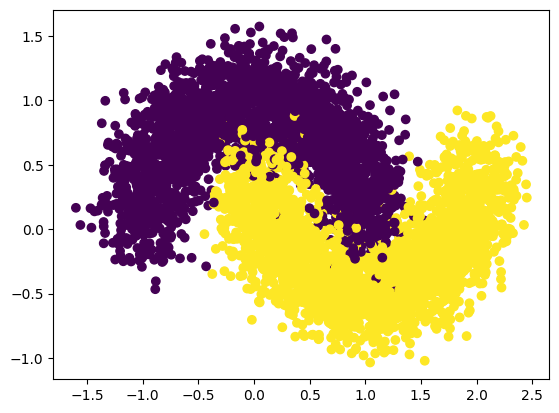

In [48]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [72]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(X.shape[1:]),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(loss="binary_crossentropy", optimizer="sgd", metrics=["accuracy"])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 500)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,101 (594.14 KB)

 Trainable params: 152,101 (594.14 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
start = time.time()
model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))
end = time.time()
tf_fittime = end - start

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8376 - loss: 0.5747 - val_accuracy: 0.8607 - val_loss: 0.4892
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8656 - loss: 0.4332 - val_accuracy: 0.8622 - val_loss: 0.3846
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8677 - loss: 0.3546 - val_accuracy: 0.8622 - val_loss: 0.3325
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8703 - loss: 0.3173 - val_accuracy: 0.8607 - val_loss: 0.3086
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8703 - loss: 0.2996 - val_accuracy: 0.8607 - val_loss: 0.2964
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8724 - loss: 0.2901 - val_accuracy: 0.8667 - val_loss: 0.2890
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8745 - loss: 0.2841 - val_accuracy: 0.8681 - val_loss: 0.2837
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8761 - loss: 0.2798 - val_accuracy: 

In [74]:
loss, tf_acc = model.evaluate(X_test, y_test)
tf_acc

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9280 - loss: 0.2076 


0.9279999732971191

In [68]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier

models = [MLPClassifier((500, 300), solver='sgd', random_state=42),
          RandomForestClassifier(random_state=42),
          KNeighborsClassifier(),
          SGDClassifier(random_state=42)
]

model_names = ['TF Sequential', 'MLPClassifier', 'RandomForestClassifier', 'KNNClassifier', 'SGDClassifier']

In [69]:
fittmes = []
scores = []

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    fittmes.append(end - start)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [75]:
import numpy as np
data = np.c_[scores, fittmes]
data = np.vstack([[[tf_acc, tf_fittime]], data])

res = pd.DataFrame(data, model_names, ['Accuracy', 'Fit Time (min)'])
res['Fit Time (min)'] /= 60
res

,Accuracy,Fit Time (min)
TF Sequential,0.928,0.443726
MLPClassifier,0.930,1.579034
RandomForestClassifier,0.952,0.012800
KNNClassifier,0.956,0.000136
SGDClassifier,0.856,0.000327


### blobs

In [100]:
from sklearn.datasets import make_blobs

X, y = make_blobs(5000, centers=[[3, -3], [2, 1.5], [-3, 2]], cluster_std=[0.7, 1.1, 0.8], random_state=43)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42, shuffle=True, test_size=0.15)

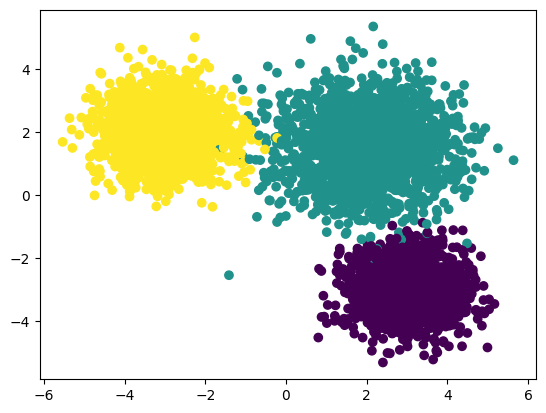

In [99]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [102]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(X.shape[1:]),
    tf.keras.layers.Dense(500, activation='relu'),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 500)            │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,703 (596.50 KB)

 Trainable params: 152,703 (596.50 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
start = time.time()
model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))
end = time.time()
tf_fittime = end - start

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9527 - loss: 0.3924 - val_accuracy: 0.9837 - val_loss: 0.1551
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9841 - loss: 0.1204 - val_accuracy: 0.9911 - val_loss: 0.0769
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9872 - loss: 0.0753 - val_accuracy: 0.9911 - val_loss: 0.0528
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9882 - loss: 0.0582 - val_accuracy: 0.9911 - val_loss: 0.0417
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9888 - loss: 0.0493 - val_accuracy: 0.9911 - val_loss: 0.0354
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9893 - loss: 0.0438 - val_accuracy: 0.9926 - val_loss: 0.0313
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9903 - loss: 0.0401 - val_accuracy: 0.9926 - val_loss: 0.0285
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9903 - loss: 0.0375 - val_accuracy: 0.

In [104]:
loss, tf_acc = model.evaluate(X_test, y_test)
tf_acc

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9920 - loss: 0.0367


0.9919999837875366

In [105]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier

models = [MLPClassifier((500, 300), solver='sgd', random_state=42),
          RandomForestClassifier(random_state=42),
          KNeighborsClassifier(),
          SGDClassifier(random_state=42)
]

model_names = ['TF Sequential', 'MLPClassifier', 'RandomForestClassifier', 'KNNClassifier', 'SGDClassifier']

In [106]:
fittmes = []
scores = []

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    fittmes.append(end - start)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

In [107]:
import numpy as np
data = np.c_[scores, fittmes]
data = np.vstack([[[tf_acc, tf_fittime]], data])

res = pd.DataFrame(data, model_names, ['Accuracy', 'Fit Time (min)'])
res['Fit Time (min)'] /= 60
res

,Accuracy,Fit Time (min)
TF Sequential,0.992,0.543915
MLPClassifier,0.992,0.947726
RandomForestClassifier,0.994,0.009254
KNNClassifier,0.992,0.000034
SGDClassifier,0.994,0.000338


## Task 2

In [3]:
from importlib import reload
import custom_keras

In [86]:
reload(custom_keras)
from custom_keras import *

model = Sequential([
    # Input([28, 28]),
    Flatten([28, 28]),
    Dense(300, 'relu'),
    Dense(100, 'relu'),
    Dense(10, 'softmax')
])

model.summary()

Model: "sequential"
----------------------------------------------------------------------------------------------------
Layer (type)                            Output Shape                            Param #             
flatten (Flatten)                       (None, 784)                             0                   
dense (Dense)                           (None, 300)                             235500              
dense_1 (Dense)                         (None, 100)                             30100               
dense_2 (Dense)                         (None, 10)                              1010                
Total params: 266610
Trainable params: 266610
Non-trainable params: 0
----------------------------------------------------------------------------------------------------


In [87]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])

In [89]:
model.get_layer('dense')